<a href="https://colab.research.google.com/github/eshwariegge/CSE-NASSCOM/blob/main/WEEK%202/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [36]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)
A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [37]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
# YOUR CODE HERE

# 2. T + T
# YOUR CODE HERE

# 3. Transpose (print .T.shape) and reshape to (2, 6)
# YOUR CODE HERE

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [38]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [39]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))



L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [43]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    # 2. cosine similarity of u and v
    # YOUR CODE HERE
    pass

# 3. Most similar pair = ?   (write your answer here)


In [44]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))


A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [45]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [46]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
# YOUR CODE HERE

# 2. M @ inv(M) == I ?
# YOUR CODE HERE

# 3. Is M symmetric? Is P orthogonal?
# YOUR CODE HERE


In [47]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)


Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


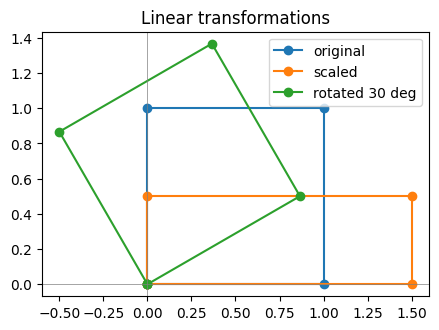

In [48]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

In [49]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
# YOUR CODE HERE

# 2. Rotation matrix (45 degrees)
# YOUR CODE HERE

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE



In [50]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
# YOUR CODE HERE

# 2. Rotation matrix (45 degrees)
# YOUR CODE HERE

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE



In [58]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
# YOUR CODE HERE

# 2. print eigenvalues
# YOUR CODE HERE

# 3. verify A v = lambda v for the first eigenvector
# YOUR CODE HERE


In [59]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [60]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')


# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

Rank of D: 2 -> < 3, so rows are dependent
cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [61]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
# YOUR CODE HERE

# 2. Rank of A2
# YOUR CODE HERE

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
# YOUR CODE HERE



In [62]:
# Core imports for the whole lab
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')      # symbolic variables we'll reuse
sp.init_printing()            # pretty-print symbolic math
np.random.seed(42)
print('Setup complete. SymPy', sp.__version__, '| NumPy', np.__version__)



Setup complete. SymPy 1.14.0 | NumPy 2.0.2


In [63]:
# -----------------------------------------------------------
# 🔹 1B. SYMBOLIC DERIVATIVE (SymPy)
# -----------------------------------------------------------

expr = x**2
deriv = sp.diff(expr, x)          # differentiate w.r.t. x
print('d/dx (x**2) =', deriv)     # 2*x

# Evaluate the symbolic derivative at x = 3
print('Symbolic f\'(3) =', deriv.subs(x, 3))

d/dx (x**2) = 2*x
Symbolic f'(3) = 6


In [64]:
def g(x):
    return x**3 + 2*x

# 1. Numerical derivative at x = 2 (use h = 1e-6)
# YOUR CODE HERE

# 2. Symbolic derivative of x**3 + 2*x
# YOUR CODE HERE

# 3. Evaluate the symbolic derivative at x = 2 and compare
# YOUR CODE HERE



In [65]:
# -----------------------------------------------------------
# 🔹 2A. PARTIAL DERIVATIVES
# -----------------------------------------------------------

f2 = x**2 + 3*x*y + y**2

# A partial derivative differentiates ONE variable, holding others fixed
print('df/dx =', sp.diff(f2, x))     # 2*x + 3*y
print('df/dy =', sp.diff(f2, y))     # 3*x + 2*y


# -----------------------------------------------------------
# 🔹 2B. THE GRADIENT (vector of partials)
# -----------------------------------------------------------

# The gradient stacks every partial derivative into one vector
grad = [sp.diff(f2, v) for v in (x, y)]
print('grad f =', grad)

# Evaluate the gradient at the point (x=1, y=2)
grad_at = [g.subs({x: 1, y: 2}) for g in grad]
print('grad f at (1, 2) =', grad_at)   # points in the steepest-ascent direction



df/dx = 2*x + 3*y
df/dy = 3*x + 2*y
grad f = [2*x + 3*y, 3*x + 2*y]
grad f at (1, 2) = [8, 7]


In [66]:

h2 = x**2 * y + sp.sin(y)

# 1. dh/dx and dh/dy
# YOUR CODE HERE

# 2. Assemble the gradient list
# YOUR CODE HERE

# 3. Evaluate at (x=2, y=0)  -> hint: .subs({x: 2, y: 0})
# YOUR CODE HERE



In [67]:
# -----------------------------------------------------------
# 🔹 3A. CHAIN RULE BY HAND vs SymPy
# -----------------------------------------------------------

# y = sin(x**2) is a composition: outer = sin(u), inner = u = x**2
# Chain rule:  dy/dx = cos(u) * du/dx = cos(x**2) * 2x
by_hand = sp.cos(x**2) * 2*x
by_sympy = sp.diff(sp.sin(x**2), x)

print('By hand :', by_hand)
print('By SymPy:', by_sympy)
print('Match?  ', sp.simplify(by_hand - by_sympy) == 0)



By hand : 2*x*cos(x**2)
By SymPy: 2*x*cos(x**2)
Match?   True


In [68]:
# -----------------------------------------------------------
# 🔹 3B. CHAINING THREE FUNCTIONS
# -----------------------------------------------------------

# y = (3x + 1)**4  -> outer^4, inner (3x+1)
expr3 = (3*x + 1)**4
print('d/dx (3x+1)^4 =', sp.diff(expr3, x))   # 12*(3x+1)^3



d/dx (3x+1)^4 = 12*(3*x + 1)**3


In [ ]:
# y = exp(x**2 + 1);  inner = x**2 + 1, inner' = 2x, outer' = exp(inner)

# 1. By hand (as a SymPy expression)
# YOUR CODE HERE

# 2. With sp.diff
# YOUR CODE HERE

# 3. Confirm they match
# YOUR CODE HERE


In [69]:
# -----------------------------------------------------------
# 🔹 4A. FORWARD PASS
# -----------------------------------------------------------

# Tiny toy problem: 4 samples, 3 input features, 5 hidden units, 1 output
X = np.random.randn(4, 3)
Y = np.random.randn(4, 1)
W1 = np.random.randn(3, 5) * 0.1
W2 = np.random.randn(5, 1) * 0.1

z1 = X @ W1                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ W2              # linear layer 2 (prediction)
loss = ((y_hat - Y) ** 2).mean()
print('Initial loss:', round(loss, 4))


# -----------------------------------------------------------
# 🔹 4B. BACKWARD PASS (gradients via the chain rule)
# -----------------------------------------------------------

# Work backwards from the loss, one link at a time
dy   = 2 * (y_hat - Y) / Y.size      # d loss / d y_hat
dW2  = h.T @ dy                      # d loss / d W2
dh   = dy @ W2.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dW1  = X.T @ dz1                     # d loss / d W1

print('dW1 shape:', dW1.shape, '(matches W1)')
print('dW2 shape:', dW2.shape, '(matches W2)')


# -----------------------------------------------------------
# 🔹 4C. ONE GRADIENT-DESCENT STEP SHOULD LOWER THE LOSS
# -----------------------------------------------------------

lr = 0.1
W1 -= lr * dW1               # step downhill
W2 -= lr * dW2

# Recompute the loss after the update
h_new = np.maximum(0, X @ W1)
loss_new = ((h_new @ W2 - Y) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')


Initial loss: 1.6936
dW1 shape: (3, 5) (matches W1)
dW2 shape: (5, 1) (matches W2)
Loss before: 1.6936
Loss after : 1.6524 -> should be lower


In [70]:
Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)
Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output

# 1. Forward pass: z1, h = ReLU(z1), y_hat, loss
# YOUR CODE HERE

# 2. Backward pass: dy, dWb, dh, dz1, dWa
# YOUR CODE HERE

# 3. One step with lr = 0.05; print loss before and after
# YOUR CODE HERE

In [71]:
# -----------------------------------------------------------
# 🔹 5A. THE HESSIAN (matrix of second derivatives = curvature)
# -----------------------------------------------------------

f5 = x**2 + 3*x*y + y**2
H = sp.hessian(f5, (x, y))
print('Hessian of f:')
sp.pprint(H)        # [[2, 3], [3, 2]]


# -----------------------------------------------------------
# 🔹 5B. GRADIENT DESCENT ON A SIMPLE FUNCTION
# -----------------------------------------------------------

# Minimise f(x) = (x - 4)**2, whose minimum is at x = 4.
# Update rule:  x <- x - lr * f'(x),  with f'(x) = 2*(x - 4)
xv = 0.0          # starting point
lr = 0.2
for step in range(15):
    grad = 2 * (xv - 4)        # the derivative
    xv = xv - lr * grad        # step against the gradient
print('Converged x:', round(xv, 3), ' (true minimum = 4)')

Hessian of f:
⎡2  3⎤
⎢    ⎥
⎣3  2⎦
Converged x: 3.998  (true minimum = 4)


In [ ]:
# 1. Hessian of x**4 + y**2
# YOUR CODE HERE

# 2. Gradient descent to minimise (x - 7)**2
# xv = 0.0; lr = 0.1
# for step in range(20):
#     grad = ...
#     xv = ...
# print('Final x:', xv)
# YOUR CODE HERE


In [72]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [73]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [74]:
# 1. Numerical vs categorical columns
# YOUR CODE HERE

# 2. Mean of a numerical column (tip)
# YOUR CODE HERE

# 3. Value counts of a categorical column (sex)
# YOUR CODE HERE

Mean   : 19.79
Median : 17.8
Mode   : 13.42
mean > median ? True -> right-skewed


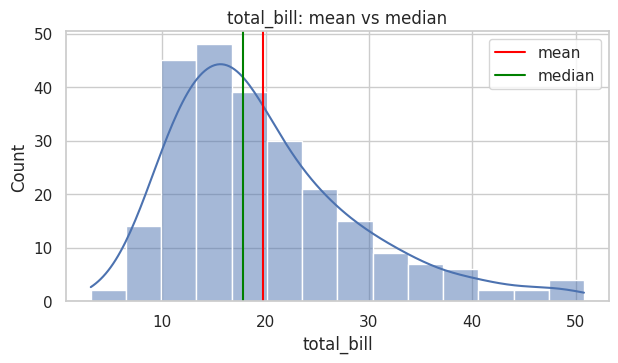

In [75]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()


In [76]:
tip = df['tip']

# 1. mean, median, mode
# YOUR CODE HERE

# 2. mean > median ?
# YOUR CODE HERE

# 3. histogram with mean & median lines (reuse the pattern from 2B)
# YOUR CODE HERE


In [77]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)


# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')



Range : 47.74
Var   : 79.25
Std   : 8.9
Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [78]:
tip = df['tip']

# 1. range, variance, std
# YOUR CODE HERE

# 2. Q1, Q3, IQR
# YOUR CODE HERE

# 3. Most robust measure of spread = ?   (write your answer here)


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


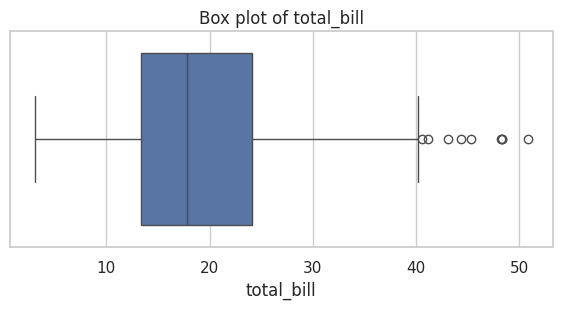

In [79]:
# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))


# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


In [80]:
tip = df['tip']

# 1. five-number summary
# YOUR CODE HERE

# 2. skewness (+ comment on the direction of the lean)
# YOUR CODE HERE

# 3. box plot of tip
# YOUR CODE HERE

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


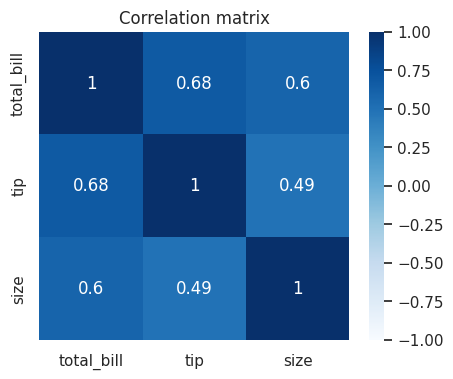

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [81]:
# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()


# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()


In [82]:
# 1. correlation matrix (rounded)
# YOUR CODE HERE

# 2. heatmap of the correlation matrix
# YOUR CODE HERE

# 3. df.describe() + 3 insights as comments
# YOUR CODE HERE
# Insight 1: ...
# Insight 2: ...
# Insight 3: ...